# Fruit Image Classification Using CNNs and Transfer Learning

**Course:** Artificial Intelligence and Machine Learning - 6CS012  
**Assessment:** Final Portfolio Assessment 2026 - Part II Vision Task  
**Group:** FruitNet  
**Student:** Saksham Sigdel (2418223)  
**Members:** Rigen Manandhar (2408621), Resman Basnet (2408565)  
**Dataset path:** `/content/drive/MyDrive/Ai/Fruit Classification`

## Research Question
How effectively can CNNs and transfer learning classify Banana, Cherry, Grape, Mango, and Peach images while handling corrupted files and moderate class imbalance?


## Result Summary

- Total training files: **6,277**
- Readable training images after cleaning: **6,242**
- Corrupted training images: **35**
- Corrupted files per class: **7**
- Smallest class after cleaning: **Mango = 908 images**
- Largest class after cleaning: **Grape = 1,468 images**
- Imbalance ratio: about **1.62:1**
- Best practical model: **Baseline CNN**, because it matched the top validation score while remaining simpler and easier to explain.

The validation scores were very high. Baseline CNN, Deeper CNN with Adam, Deeper CNN with SGD, Deeper CNN without Dropout, and MobileNetV2 reached **100% validation accuracy and F1-score** in the latest run.

This result should be explained carefully. Perfect validation performance can happen because the fruit classes are visually clear and the dataset appears to include similar augmented variants. Therefore, the model performs very well on this dataset, but the report should not claim guaranteed real-world performance.


## Run Order

1. Run setup and imports.
2. Check the dataset path.
3. Scan images and remove corrupted files.
4. Create the stratified train-validation split.
5. Train and evaluate the Baseline CNN.
6. Train and evaluate the Deeper CNN.
7. Compare Adam and SGD.
8. Run the no-dropout ablation.
9. Train and evaluate MobileNetV2.
10. Compare all models and predict the five unlabeled test images.




## 1. Setup


In [7]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Basic Python libraries
import time
import random
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, applications

# Avoid VS Code/Pylance import warning
ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator

# Plot style
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Check TensorFlow and GPU
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# Main configuration cell.
# If Colab restarts, run this cell again before the dataset and model cells.
DATASET_ROOT = "/content/drive/MyDrive/Ai/Fruit Classification"

# Train contains labelled fruit folders. Test contains unlabeled images.
TRAIN_DIR = Path(DATASET_ROOT) / "Train"
TEST_DIR = Path(DATASET_ROOT) / "Test"

# Fixed class order keeps labels consistent in every generator and report.
CLASS_NAMES = ["Banana", "Cherry", "Grape", "Mango", "Peach"]
NUM_CLASSES = len(CLASS_NAMES)

# Scratch CNNs use the dataset's native 100 x 100 image size.
# MobileNetV2 needs 224 x 224 because it was pretrained on ImageNet.
IMG_SIZE_SCRATCH = (100, 100)
IMG_SIZE_TRANSFER = (224, 224)

BATCH_SIZE = 32
VALIDATION_SIZE = 0.20

# Epoch values are kept moderate for Colab runtime.
EPOCHS_BASELINE = 8
EPOCHS_DEEP = 8
EPOCHS_OPTIMIZER = 6
EPOCHS_ABLATION = 6
EPOCHS_TRANSFER_HEAD = 4
EPOCHS_TRANSFER_FINE_TUNE = 4

# Keep False to avoid negative-looking processed fruit image grids.
SHOW_IMAGE_GRIDS = False

# This prevents NameError if the Drive mount cell was skipped.
if "IN_COLAB" not in globals():
    IN_COLAB = Path("/content").exists()

OUTPUT_DIR = Path("/content/fruitnet_outputs") if IN_COLAB else Path("fruitnet_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_ROOT)
print("Train path exists:", TRAIN_DIR.exists())
print("Test path exists:", TEST_DIR.exists())
print("Image grids enabled:", SHOW_IMAGE_GRIDS)
print("Output directory:", OUTPUT_DIR)


Dataset: /content/drive/MyDrive/Ai/Fruit Classification
Train path exists: True
Test path exists: True
Image grids enabled: False
Output directory: /content/fruitnet_outputs


## 2. Dataset Check and Cleaning


In [10]:
def check_dataset_layout():
    required_paths = [TRAIN_DIR, TEST_DIR] + [TRAIN_DIR / name for name in CLASS_NAMES]
    missing = [str(path) for path in required_paths if not path.exists()]

    if missing:
        raise FileNotFoundError("Fix DATASET_ROOT. Missing paths:\n" + "\n".join(missing))

    print("Dataset layout is correct.")

check_dataset_layout()


Dataset layout is correct.


In [11]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def image_files(folder):
    return sorted(path for path in Path(folder).rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)

def is_readable_image(path):
    try:
        with Image.open(path) as image:
            image.verify()
        return True, ""
    except Exception as error:
        return False, f"{type(error).__name__}: {error}"

records = []
corrupted = []

for label in CLASS_NAMES:
    for path in image_files(TRAIN_DIR / label):
        ok, reason = is_readable_image(path)
        row = {"filepath": str(path), "label": label, "filename": path.name}
        if ok:
            records.append(row)
        else:
            row["reason"] = reason
            corrupted.append(row)

image_df = pd.DataFrame(records)
corrupted_df = pd.DataFrame(corrupted)
test_files = image_files(TEST_DIR)

print("Readable training images:", len(image_df))
print("Corrupted training images:", len(corrupted_df))
print("Unlabeled test images:", len(test_files))

if len(corrupted_df):
    display(corrupted_df.groupby("label").size().rename("corrupted_count").reset_index())


Readable training images: 6242
Corrupted training images: 35
Unlabeled test images: 5


,label,corrupted_count
0,Banana,7
1,Cherry,7
2,Grape,7
3,Mango,7
4,Peach,7


,class,total_files,readable_images,corrupted_files
0,Banana,1429,1422,7
1,Cherry,1229,1222,7
2,Grape,1475,1468,7
3,Mango,915,908,7
4,Peach,1229,1222,7


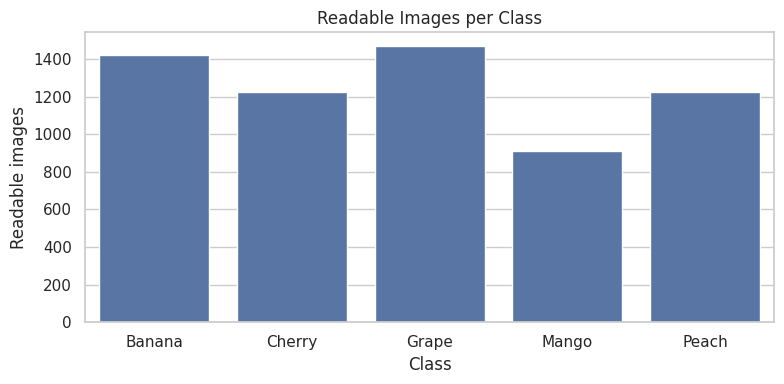

In [12]:
total_counts = pd.Series({name: len(image_files(TRAIN_DIR / name)) for name in CLASS_NAMES}, name="total_files")
readable_counts = image_df["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
corrupted_counts = total_counts - readable_counts

class_summary = pd.DataFrame({
    "class": CLASS_NAMES,
    "total_files": total_counts.values,
    "readable_images": readable_counts.values,
    "corrupted_files": corrupted_counts.values,
})

display(class_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=class_summary, x="class", y="readable_images")
plt.title("Readable Images per Class")
plt.xlabel("Class")
plt.ylabel("Readable images")
plt.tight_layout()
plt.show()


## 3. Train-Validation Split


,train,validation
label,,
Banana,1137,285
Cherry,978,244
Grape,1174,294
Mango,726,182
Peach,978,244


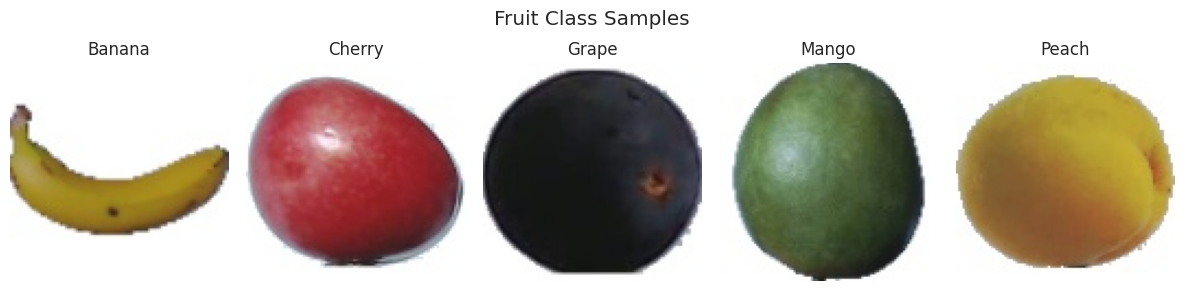

In [13]:
train_df, val_df = train_test_split(
    image_df,
    test_size=VALIDATION_SIZE,
    stratify=image_df["label"],
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts().reindex(CLASS_NAMES),
    "validation": val_df["label"].value_counts().reindex(CLASS_NAMES),
}).astype(int)

display(split_summary)

# Display only normal fruit images, one from each class.
# This uses original image files, so it will not show negative-color processed images.
plt.figure(figsize=(12, 3))
for index, fruit in enumerate(CLASS_NAMES, start=1):
    sample_path = train_df.loc[train_df["label"] == fruit, "filepath"].iloc[0]
    image = Image.open(sample_path).convert("RGB").resize(IMG_SIZE_SCRATCH)

    plt.subplot(1, len(CLASS_NAMES), index)
    plt.imshow(image)
    plt.title(fruit)
    plt.axis("off")

plt.suptitle("Fruit Class Samples")
plt.tight_layout()
plt.show()

In [14]:
scratch_train_datagen = ImageDataGenerator(
    rescale=1 / 255.0,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

scratch_val_datagen = ImageDataGenerator(rescale=1 / 255.0)

scratch_train_gen = scratch_train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE_SCRATCH,
    classes=CLASS_NAMES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

scratch_val_gen = scratch_val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE_SCRATCH,
    classes=CLASS_NAMES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Found 4993 validated image filenames belonging to 5 classes.
Found 1249 validated image filenames belonging to 5 classes.


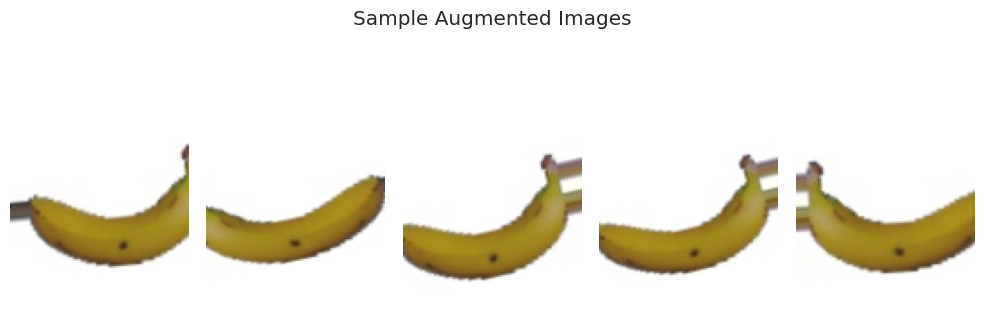

In [15]:
sample_path = train_df.iloc[0]["filepath"]

img = keras.utils.load_img(sample_path, target_size=IMG_SIZE_SCRATCH)
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)

aug_iter = scratch_train_datagen.flow(x, batch_size=1)

plt.figure(figsize=(10, 4))
for i in range(5):
    batch = next(aug_iter)
    plt.subplot(1, 5, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")

plt.suptitle("Sample Augmented Images")
plt.tight_layout()
plt.show()

## 4. Evaluation Helpers


In [ ]:
# Helper functions used by every model.
# RESULTS stores one final row for each model name.
RESULTS = []

def plot_history(history, title):
    # Plot training and validation curves so overfitting can be checked visually.
    data = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(data["loss"], label="train")
    axes[0].plot(data["val_loss"], label="validation")
    axes[0].set_title(f"{title}: Loss")
    axes[0].legend()

    axes[1].plot(data["accuracy"], label="train")
    axes[1].plot(data["val_accuracy"], label="validation")
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def evaluate_model(model, generator, model_name, training_time):
    # Use the validation generator without shuffling so predictions align with labels.
    generator.reset()
    probabilities = model.predict(generator, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = generator.classes

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "training_time_seconds": training_time,
    }

    # Replace old results for the same model. This avoids duplicate rows if a cell is rerun.
    global RESULTS
    RESULTS = [row for row in RESULTS if row["model"] != model_name]
    RESULTS.append(result)

    display(pd.DataFrame([result]))
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return result

def training_callbacks():
    # EarlyStopping saves time and restores the best validation-loss weights.
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
    ]


## 5. Baseline CNN


In [ ]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE_SCRATCH + (3,)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,853,573 (18.51 MB)

 Trainable params: 4,853,573 (18.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 281ms/step - accuracy: 0.8526 - loss: 0.3670 - val_accuracy: 0.8671 - val_loss: 0.5256 - learning_rate: 0.0010
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.9882 - loss: 0.0374 - val_accuracy: 1.0000 - val_loss: 2.9824e-04 - learning_rate: 0.0010
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.9880 - val_loss: 0.0400 - learning_rate: 0.0010
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.9938 - loss: 0.0186 - val_accuracy: 1.0000 - val_loss: 3.5186e-05 - learning_rate: 0.0010
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 233ms/step - accuracy: 0.9878 - loss: 0.0428 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 225ms/step - accuracy: 0.9930 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 1.8331e-04 - learning_rate: 0.0010
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy

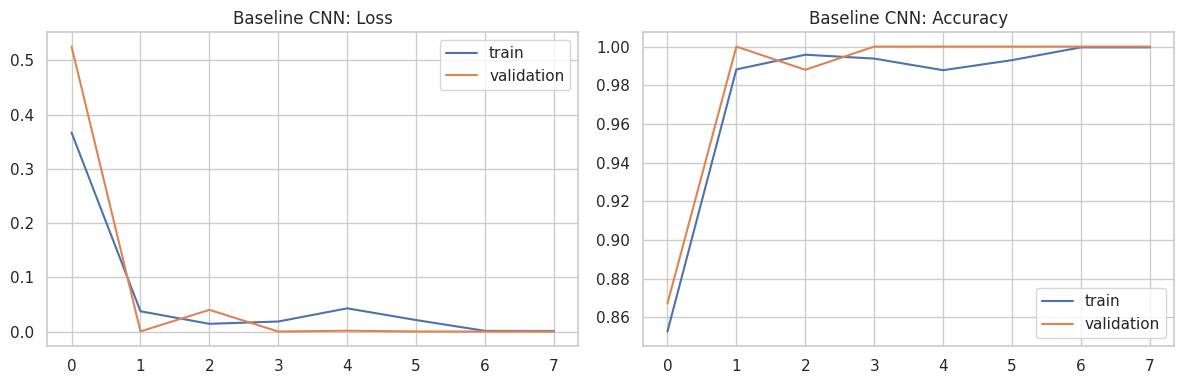

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Baseline CNN,1.0,1.0,1.0,1.0,302.068732


              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       285
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       294
       Mango       1.00      1.00      1.00       182
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



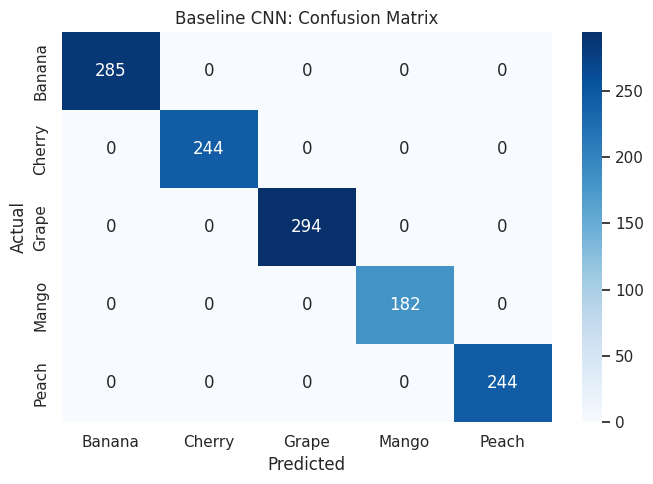

In [ ]:
# Rebuild the baseline model here so rerunning this cell starts fresh.
baseline_model = build_baseline_cnn()

start = time.perf_counter()
baseline_history = baseline_model.fit(
    scratch_train_gen,
    validation_data=scratch_val_gen,
    epochs=EPOCHS_BASELINE,
    callbacks=training_callbacks(),
)
baseline_time = time.perf_counter() - start

plot_history(baseline_history, "Baseline CNN")
baseline_result = evaluate_model(baseline_model, scratch_val_gen, "Baseline CNN", baseline_time)


## 6. Deeper CNN with Regularization


In [ ]:
def build_deeper_cnn(optimizer_name="adam", use_dropout=True):
    inputs = keras.Input(shape=IMG_SIZE_SCRATCH + (3,))
    x = inputs

    for filters, drop_rate in [(32, 0.25), (64, 0.30), (128, 0.40)]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        if use_dropout:
            x = layers.Dropout(drop_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    if use_dropout:
        x = layers.Dropout(0.50)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    optimizer = optimizers.Adam(1e-3)
    if optimizer_name == "sgd":
        optimizer = optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

deep_adam_model = build_deeper_cnn("adam", use_dropout=True)
deep_adam_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 5,042,213 (19.23 MB)

 Trainable params: 5,040,805 (19.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 285ms/step - accuracy: 0.9355 - loss: 0.1885 - val_accuracy: 0.2354 - val_loss: 4.3902 - learning_rate: 0.0010
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.9764 - loss: 0.0772 - val_accuracy: 0.4916 - val_loss: 2.7440 - learning_rate: 0.0010
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy: 0.9912 - loss: 0.0287 - val_accuracy: 0.9303 - val_loss: 0.1683 - learning_rate: 0.0010
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.9960 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.9934 - loss: 0.0206 - val_accuracy: 0.9976 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 242ms/step - accuracy: 0.9914 - loss: 0.0257 - val_accuracy: 1.0000 - val_loss: 1.9825e-04 - learning_rate: 0.0010
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 236ms/step - accuracy: 0.9930

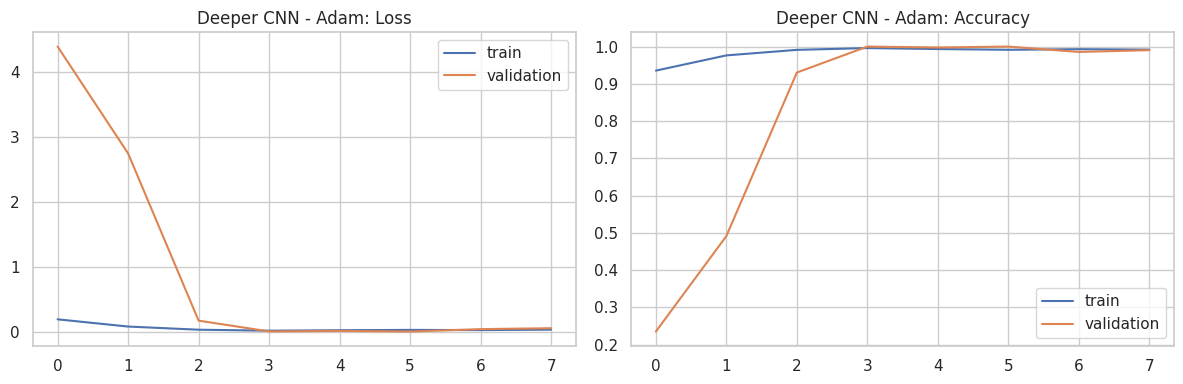

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Deeper CNN - Adam,1.0,1.0,1.0,1.0,315.447773


              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       285
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       294
       Mango       1.00      1.00      1.00       182
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



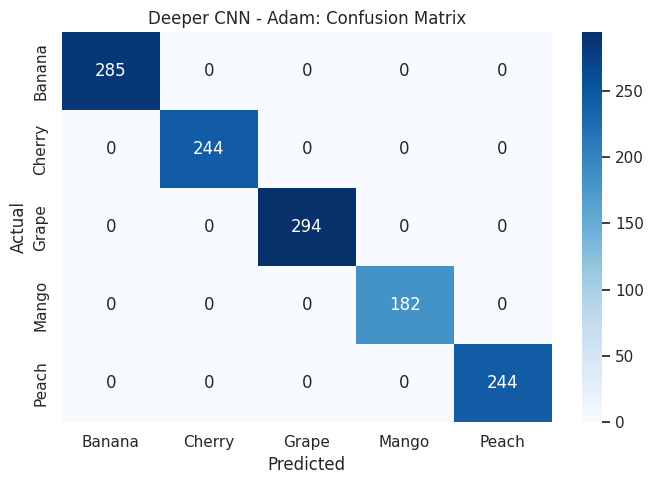

In [ ]:
# Rebuild the deeper Adam model here so rerunning this cell does not continue old training.
deep_adam_model = build_deeper_cnn("adam", use_dropout=True)

start = time.perf_counter()
deep_adam_history = deep_adam_model.fit(
    scratch_train_gen,
    validation_data=scratch_val_gen,
    epochs=EPOCHS_DEEP,
    callbacks=training_callbacks(),
)
deep_adam_time = time.perf_counter() - start

plot_history(deep_adam_history, "Deeper CNN - Adam")
deep_adam_result = evaluate_model(deep_adam_model, scratch_val_gen, "Deeper CNN - Adam", deep_adam_time)


## 7. Optimizer Comparison: SGD vs Adam


Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 272ms/step - accuracy: 0.9155 - loss: 0.2493 - val_accuracy: 0.7086 - val_loss: 2.8940 - learning_rate: 0.0100
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 225ms/step - accuracy: 0.9806 - loss: 0.0619 - val_accuracy: 0.8927 - val_loss: 0.8843 - learning_rate: 0.0100
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy: 0.9938 - loss: 0.0245 - val_accuracy: 0.9944 - val_loss: 0.0192 - learning_rate: 0.0100
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.9920 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0100
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 233ms/step - accuracy: 0.9928 - loss: 0.0234 - val_accuracy: 0.9384 - val_loss: 0.1720 - learning_rate: 0.0100
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.9884 - loss: 0.0395 - val_accuracy: 1.0000 - val_loss: 1.9784e-04 - learning_rate: 0.0100


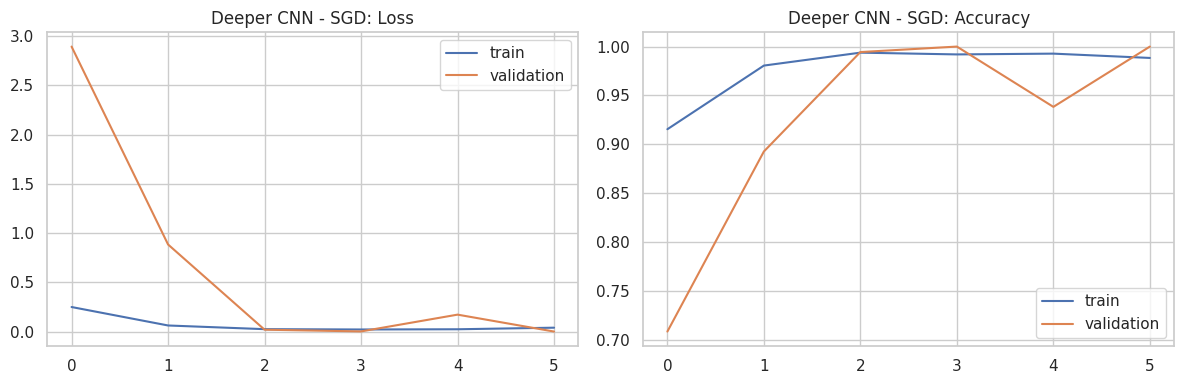

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Deeper CNN - SGD,1.0,1.0,1.0,1.0,232.212676


              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       285
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       294
       Mango       1.00      1.00      1.00       182
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



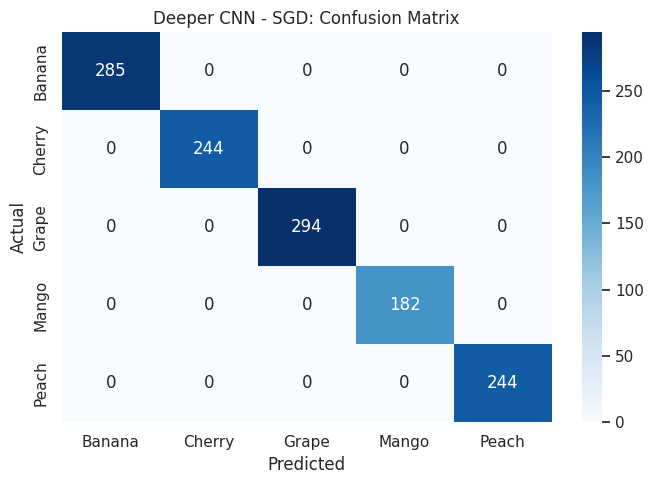

In [ ]:
# Train the same deeper architecture with SGD to compare optimizer behavior against Adam.
deep_sgd_model = build_deeper_cnn("sgd", use_dropout=True)

start = time.perf_counter()
deep_sgd_history = deep_sgd_model.fit(
    scratch_train_gen,
    validation_data=scratch_val_gen,
    epochs=EPOCHS_OPTIMIZER,
    callbacks=training_callbacks(),
)
deep_sgd_time = time.perf_counter() - start

plot_history(deep_sgd_history, "Deeper CNN - SGD")
deep_sgd_result = evaluate_model(deep_sgd_model, scratch_val_gen, "Deeper CNN - SGD", deep_sgd_time)


## 8. Ablation Study: Remove Dropout


Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 263ms/step - accuracy: 0.9637 - loss: 0.1091 - val_accuracy: 0.2650 - val_loss: 2.1776 - learning_rate: 0.0010
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.9838 - loss: 0.0567 - val_accuracy: 0.3643 - val_loss: 9.6643 - learning_rate: 0.0010
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.9850 - loss: 0.0458 - val_accuracy: 0.6613 - val_loss: 1.3056 - learning_rate: 0.0010
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.9914 - loss: 0.0285 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.9908 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 1.9771e-04 - learning_rate: 0.0010
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.9938 - loss: 0.0175 - val_accuracy: 0.9968 - val_loss: 0.0059 - learning_rate: 0.0010


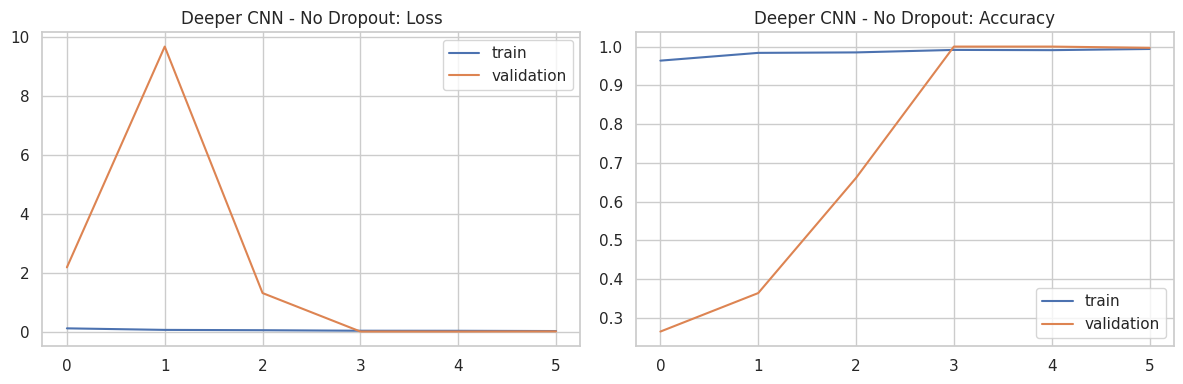

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Deeper CNN - No Dropout,1.0,1.0,1.0,1.0,239.467451


              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       285
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       294
       Mango       1.00      1.00      1.00       182
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



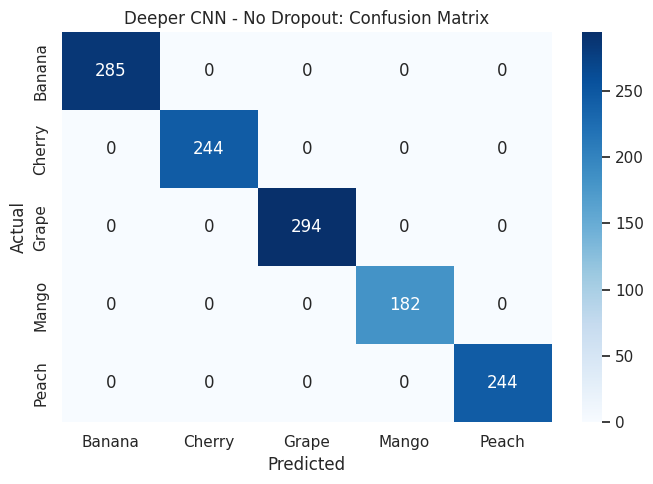

In [ ]:
# Ablation study: remove Dropout but keep the rest of the deeper CNN the same.
# This checks whether Dropout is actually helping generalization.
no_dropout_model = build_deeper_cnn("adam", use_dropout=False)

start = time.perf_counter()
no_dropout_history = no_dropout_model.fit(
    scratch_train_gen,
    validation_data=scratch_val_gen,
    epochs=EPOCHS_ABLATION,
    callbacks=training_callbacks(),
)
no_dropout_time = time.perf_counter() - start

plot_history(no_dropout_history, "Deeper CNN - No Dropout")
no_dropout_result = evaluate_model(no_dropout_model, scratch_val_gen, "Deeper CNN - No Dropout", no_dropout_time)


## 9. Transfer Learning with MobileNetV2


In [ ]:
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)
transfer_val_datagen = ImageDataGenerator(preprocessing_function=applications.mobilenet_v2.preprocess_input)

transfer_train_gen = transfer_train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE_TRANSFER,
    classes=CLASS_NAMES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
transfer_val_gen = transfer_val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE_TRANSFER,
    classes=CLASS_NAMES,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Found 4993 validated image filenames belonging to 5 classes.
Found 1249 validated image filenames belonging to 5 classes.


In [ ]:
def build_mobilenetv2():
    base = applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE_TRANSFER + (3,),
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE_TRANSFER + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model, base

transfer_model, mobilenet_base = build_mobilenetv2()
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 123s 661ms/step - accuracy: 0.9309 - loss: 0.2212 - val_accuracy: 0.9960 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 536ms/step - accuracy: 0.9954 - loss: 0.0348 - val_accuracy: 1.0000 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 533ms/step - accuracy: 0.9976 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 527ms/step - accuracy: 0.9992 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 117s 635ms/step - accuracy: 0.8612 - loss: 0.3497 - val_accuracy: 0.9992 - val_loss: 0.0055 - learning_rate: 1.0000e-05
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 532ms/step - accuracy: 0.9864 - loss: 0.0513 - val_accuracy: 0.9992 - val_loss: 0.0042 - learning_rate: 1.0000e-05
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 526ms/step - accuracy: 

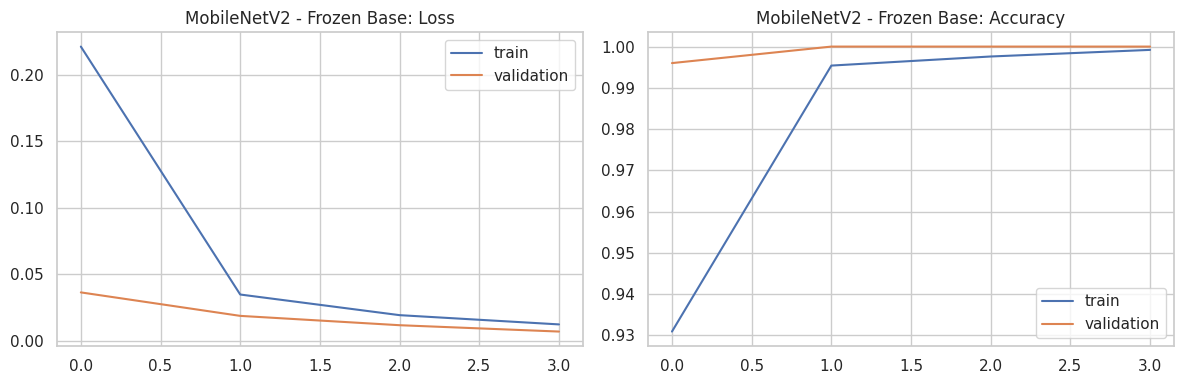

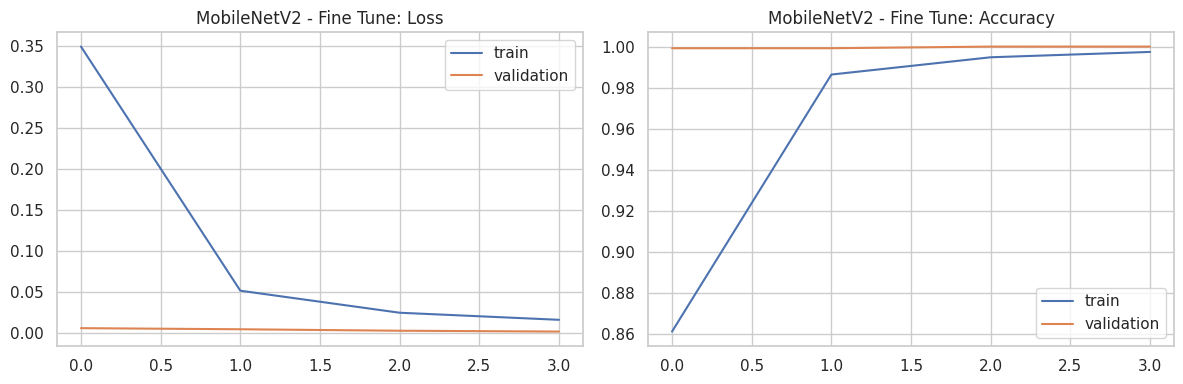

40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,MobileNetV2 Transfer Learning,1.0,1.0,1.0,1.0,740.477974


              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       285
      Cherry       1.00      1.00      1.00       244
       Grape       1.00      1.00      1.00       294
       Mango       1.00      1.00      1.00       182
       Peach       1.00      1.00      1.00       244

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



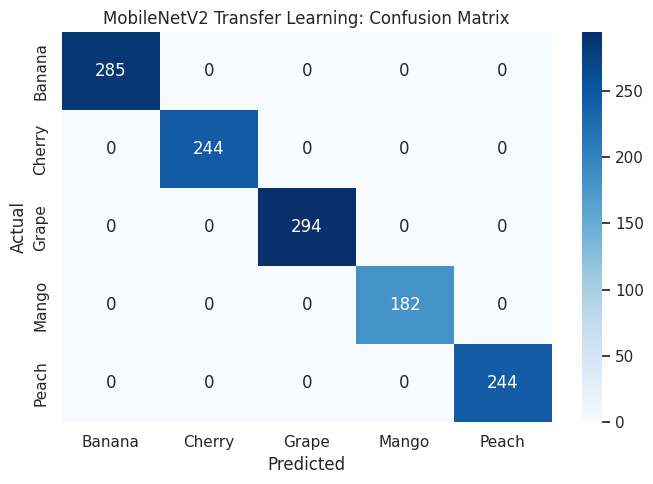

In [ ]:
# Rebuild MobileNetV2 here so rerunning this cell starts a clean transfer-learning run.
transfer_model, mobilenet_base = build_mobilenetv2()

start = time.perf_counter()

# Stage 1: freeze pretrained convolutional layers and train only the new classifier.
head_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=EPOCHS_TRANSFER_HEAD,
    callbacks=training_callbacks(),
)

# Stage 2: unfreeze the last layers and fine-tune with a very small learning rate.
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=EPOCHS_TRANSFER_FINE_TUNE,
    callbacks=training_callbacks(),
)

transfer_time = time.perf_counter() - start

plot_history(head_history, "MobileNetV2 - Frozen Base")
plot_history(fine_tune_history, "MobileNetV2 - Fine Tune")
transfer_result = evaluate_model(transfer_model, transfer_val_gen, "MobileNetV2 Transfer Learning", transfer_time)


## 10. Final Model Comparison


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Baseline CNN,1.0,1.0,1.0,1.0,302.068732
1,Deeper CNN - Adam,1.0,1.0,1.0,1.0,315.447773
2,Deeper CNN - SGD,1.0,1.0,1.0,1.0,232.212676
3,Deeper CNN - No Dropout,1.0,1.0,1.0,1.0,239.467451
4,MobileNetV2 Transfer Learning,1.0,1.0,1.0,1.0,740.477974


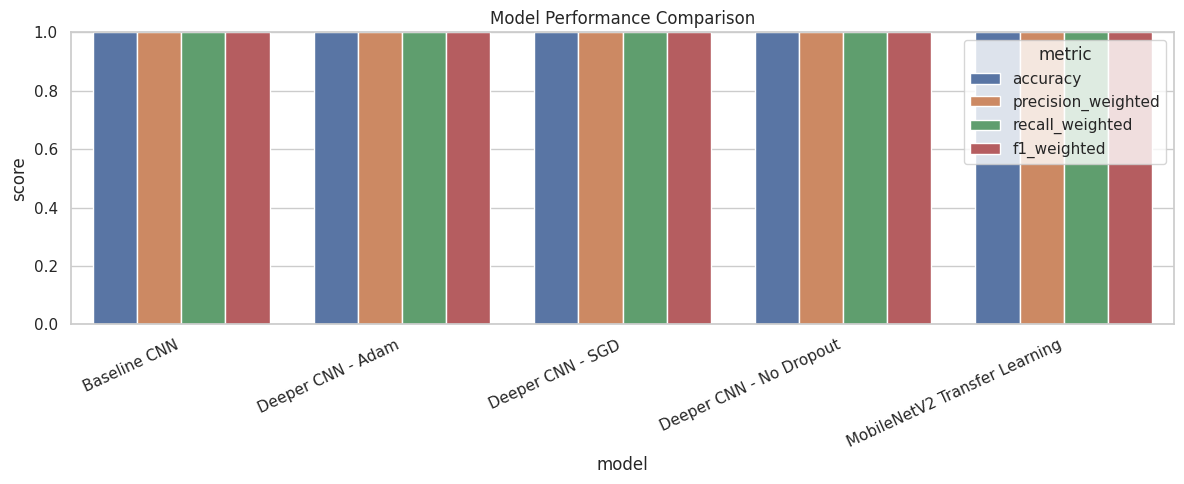

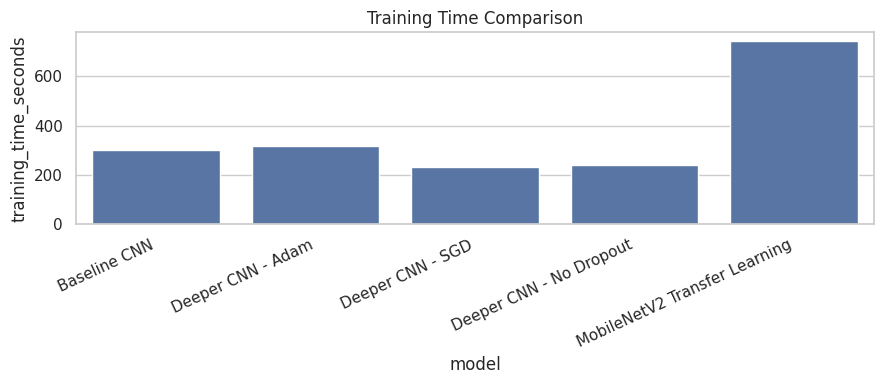

In [ ]:
# Build the final comparison table.
# drop_duplicates is included as an extra safety check if any model was evaluated more than once.
results_df = (
    pd.DataFrame(RESULTS)
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("f1_weighted", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

metric_cols = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]
results_long = results_df.melt(id_vars="model", value_vars=metric_cols, var_name="metric", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=results_long, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="model", y="training_time_seconds")
plt.title("Training Time Comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 11. Predict the Five Unlabeled Test Images


In [ ]:
def predict_test_images(model):
    rows = []
    images = []

    for path in test_files:
        image = Image.open(path).convert("RGB").resize(IMG_SIZE_TRANSFER)
        images.append(np.array(image, dtype=np.float32))

    inputs = applications.mobilenet_v2.preprocess_input(np.array(images))
    probabilities = model.predict(inputs, verbose=0)
    predicted_indices = np.argmax(probabilities, axis=1)

    for path, class_index, probs in zip(test_files, predicted_indices, probabilities):
        rows.append({
            "filename": path.name,
            "predicted_class": CLASS_NAMES[class_index],
            "confidence": float(probs[class_index]),
        })

    prediction_df = pd.DataFrame(rows)
    display(prediction_df)
    prediction_df.to_csv(OUTPUT_DIR / "fruitnet_test_predictions.csv", index=False)
    return prediction_df

test_predictions_df = predict_test_images(transfer_model)


,filename,predicted_class,confidence
0,11_100.jpg,Mango,0.999971
1,14_100.jpg,Grape,0.999684
2,1_100(2).jpg,Banana,1.000000
3,26_100.jpg,Peach,0.999767
4,5_100.jpg,Cherry,0.785503


The notebook result is very strong because every main model reached perfect validation accuracy and weighted F1-score on the validation split. This means the dataset is highly learnable for CNN-based image classification.

The result should still be discussed carefully. Perfect validation performance may happen because the five fruit classes are visually distinct and because the dataset appears to contain similar augmented image variants. For this reason, the validation result is excellent for the provided dataset, but it should not be presented as guaranteed real-world performance.

The final model choice should consider both accuracy and efficiency. Since all models reached the same validation score, the simpler or faster model is usually the better practical choice. The baseline CNN is easiest to explain and satisfies the coursework requirement. MobileNetV2 is useful as a transfer-learning comparison, but it is heavier and did not provide a clear validation improvement in this run.
